Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd

In [6]:
import os
print(os.getcwd())

/Users/tekabe/Downloads/KAIM Week4/credit-risk-model/notebooks


In [7]:
df = pd.read_csv("../Data/data.csv")

Checking the columns, number of rows and data types

In [8]:
# Check rows, columns, and memory usage
print(df.info())

# Get a glimpse of the first few rows
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

Summary Statistics

In [9]:
# Statistical summary for numerical columns
print(df.describe())

# Statistical summary for categorical columns
print(df.describe(include=['object']))

       CountryCode        Amount         Value  PricingStrategy   FraudResult
count      95662.0  9.566200e+04  9.566200e+04     95662.000000  95662.000000
mean         256.0  6.717846e+03  9.900584e+03         2.255974      0.002018
std            0.0  1.233068e+05  1.231221e+05         0.732924      0.044872
min          256.0 -1.000000e+06  2.000000e+00         0.000000      0.000000
25%          256.0 -5.000000e+01  2.750000e+02         2.000000      0.000000
50%          256.0  1.000000e+03  1.000000e+03         2.000000      0.000000
75%          256.0  2.800000e+03  5.000000e+03         2.000000      0.000000
max          256.0  9.880000e+06  9.880000e+06         4.000000      1.000000


/var/folders/d9/fl1vk6zx3p950w23l303nhy40000gn/T/ipykernel_731/947389825.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=['object']))


              TransactionId        BatchId       AccountId  \
count                 95662          95662           95662   
unique                95662          94809            3633   
top     TransactionId_76871  BatchId_67019  AccountId_4841   
freq                      1             28           30893   

             SubscriptionId       CustomerId CurrencyCode    ProviderId  \
count                 95662            95662        95662         95662   
unique                 3627             3742            1             6   
top     SubscriptionId_3829  CustomerId_7343          UGX  ProviderId_4   
freq                  32630             4091        95662         38189   

          ProductId     ProductCategory    ChannelId  TransactionStartTime  
count         95662               95662        95662                 95662  
unique           23                   9            4                 94556  
top     ProductId_6  financial_services  ChannelId_3  2018-12-24T16:30:13Z  
freq 

Distribution of Numerical Features

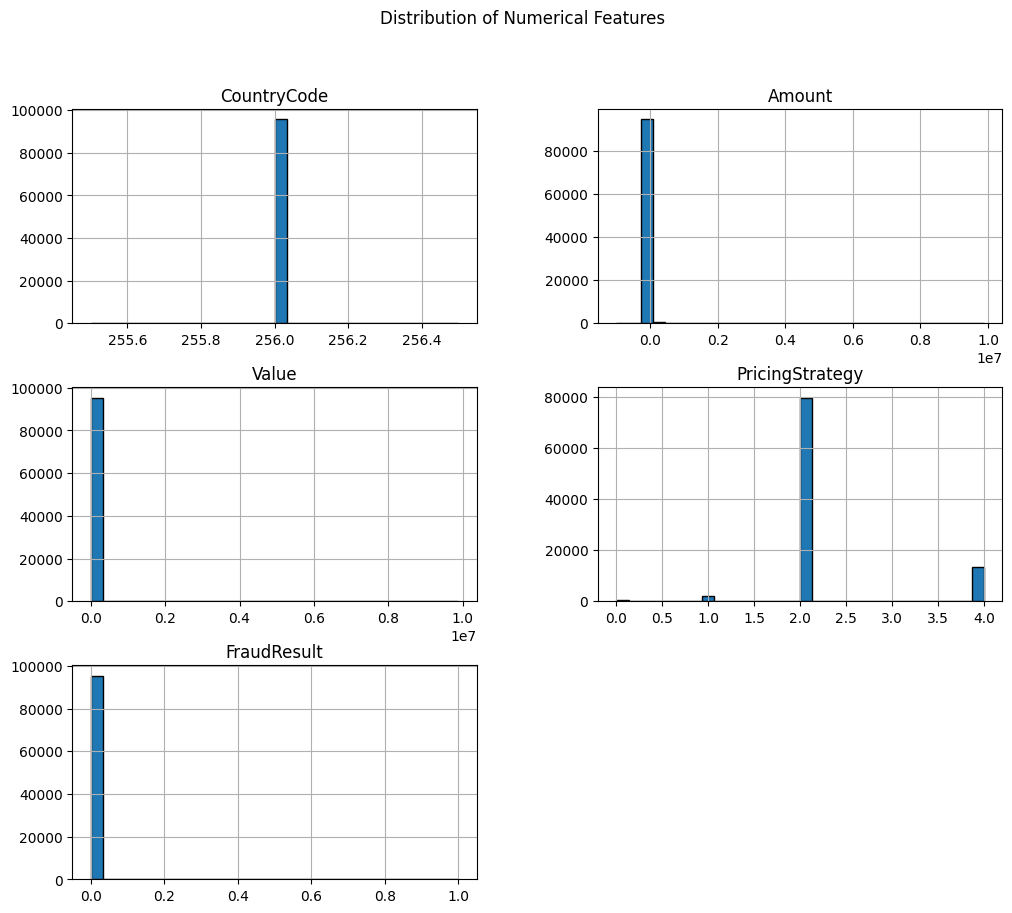

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histograms for all numerical columns
df.hist(figsize=(12, 10), bins=30, edgecolor='black')
plt.suptitle('Distribution of Numerical Features')
plt.show()

Distribution of Categorical Features

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Your countplot code follows...

In [15]:
print(df.columns)

Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',
       'ProductCategory', 'ChannelId', 'Amount', 'Value',
       'TransactionStartTime', 'PricingStrategy', 'FraudResult'],
      dtype='str')


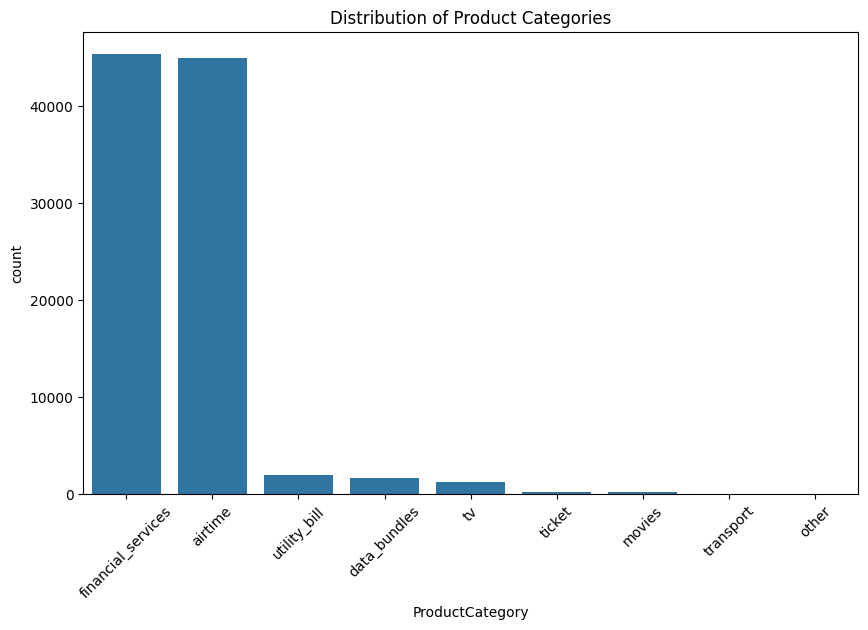

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Using ProductCategory as our categorical feature
sns.countplot(data=df, x='ProductCategory', order=df['ProductCategory'].value_counts().index)
plt.title('Distribution of Product Categories')
plt.xticks(rotation=45)
plt.show()

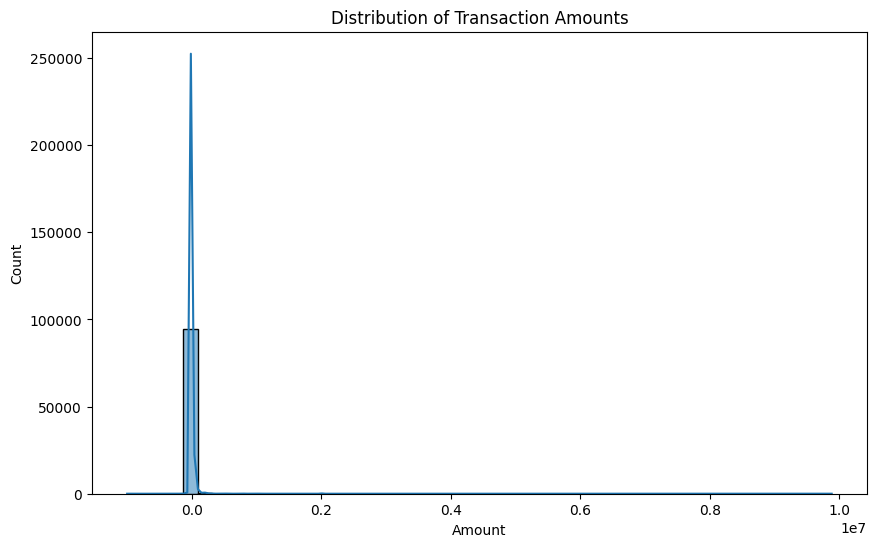

In [17]:
# Histogram for transaction values
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amounts')
plt.show()

correlation analysis

The categorical column one 1st

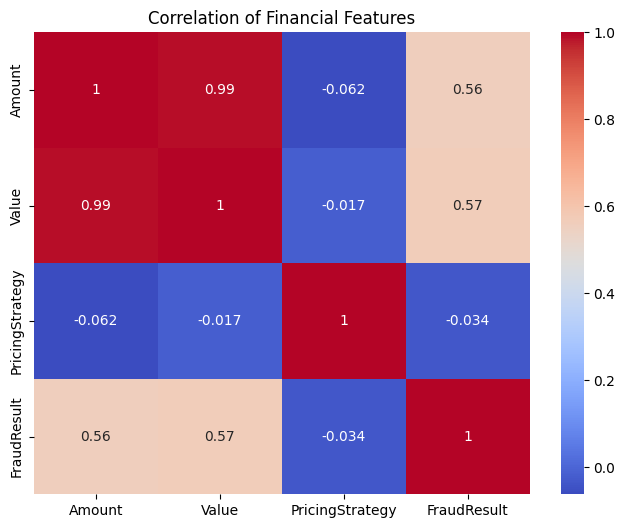

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Amount', 'Value', 'PricingStrategy', 'FraudResult']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation of Financial Features')
plt.show()

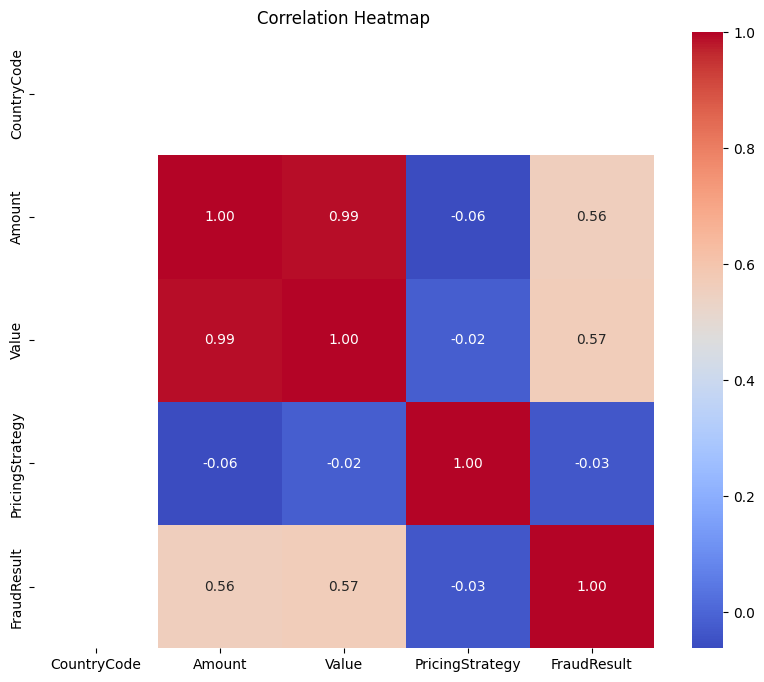

In [19]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

Identifying Missing Values

In [21]:
# Count missing values per column
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Visualize missing data with a heatmap
# sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
# plt.title('Missing Values Map')
# plt.show()

Series([], dtype: int64)


Outlier

In [22]:
# Visualize outliers for a specific feature like 'Score'
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Score'])
plt.title('Outlier Detection for Score')
plt.show()

KeyError: 'Score'

<Figure size 800x500 with 0 Axes>